In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [11]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,    # not take dense layer
    input_shape=(150,150,3),

)

In [12]:
conv_base.trainable = True
set_trainable = False

for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
    print(layer.name,layer.trainable)

input_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [13]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [14]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [18]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = 'archive/train',
    labels='inferred',
    label_mode = 'int',
    batch_size = 16,
    image_size = (150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'archive/test',
    labels='inferred',
    label_mode = 'int',
    batch_size = 16,
    image_size = (150,150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [19]:
# normalize
def process(image,label):
    image = tensorflow.cast(image/255.,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [20]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train_ds,epochs=5,validation_data=validation_ds)

Epoch 1/5


1250/1250 [==============================] - 94s 65ms/step - loss: 0.2201 - accuracy: 0.9074 - val_loss: 0.1806 - val_accuracy: 0.9226
Epoch 2/5
1250/1250 [==============================] - 80s 64ms/step - loss: 0.1193 - accuracy: 0.9540 - val_loss: 0.1373 - val_accuracy: 0.9454
Epoch 3/5
1250/1250 [==============================] - 81s 64ms/step - loss: 0.0775 - accuracy: 0.9716 - val_loss: 0.1238 - val_accuracy: 0.9522
Epoch 4/5
1250/1250 [==============================] - 81s 64ms/step - loss: 0.0489 - accuracy: 0.9838 - val_loss: 0.1913 - val_accuracy: 0.9358
Epoch 5/5
1250/1250 [==============================] - 81s 65ms/step - loss: 0.0290 - accuracy: 0.9916 - val_loss: 0.1691 - val_accuracy: 0.9468


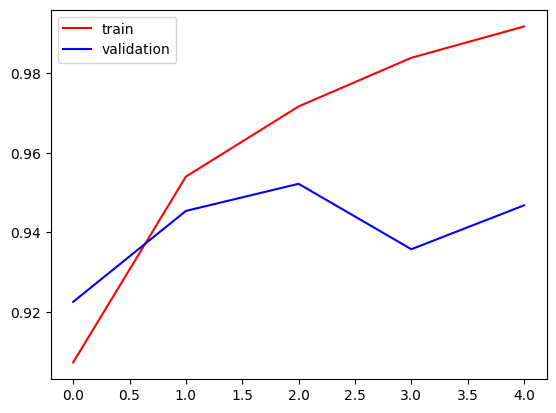

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

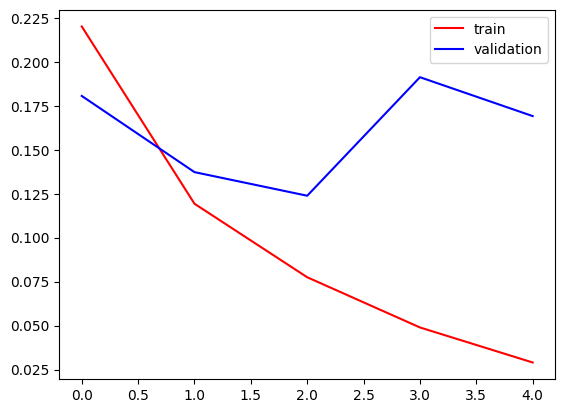

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()